# Model Comparison — Pass/Fail Prediction

Compares the three models on the **same** train/test split: Logistic Regression, XGBoost and the MLP.

For the full wandb logging (confusion matrices + ROC curves per model) run from the `part3/` folder:

```bash
poetry run python -m src.train
```

This notebook reproduces the metrics in-process for a quick side-by-side table and chart.

In [1]:
import os, sys

# Make the part3/ package importable and data/ paths resolvable from notebooks/.
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)
os.chdir(ROOT)

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features import build_dataset
from src.metrics import compute_metrics
from src.models.sklearn_models import build_logreg, build_xgboost

with open("config.yaml") as f:
    config = yaml.safe_load(f)

dataset = build_dataset(config)
print(f"features={dataset.input_dim}  train={len(dataset.y_train)}  test={len(dataset.y_test)}")

Loading and cleaning quiz data for SemesterY...
Loading and cleaning exam data for SemesterY...
Merging quiz and exam data for SemesterY...
Loading and cleaning quiz data for SemesterX...
Loading and cleaning exam data for SemesterX...
Merging quiz and exam data for SemesterX...
features=222  train=108  test=27


C:\FHNW_Programmiersachen\8_sem\P-BI-MMI\part3\src\features.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


## Logistic Regression & XGBoost

In [2]:
results = {}

for name, build_fn in [("LogisticRegression", build_logreg), ("XGBoost", build_xgboost)]:
    model = build_fn(config)
    model.fit(dataset.X_train, dataset.y_train)
    y_pred = model.predict(dataset.X_test)
    y_prob = model.predict_proba(dataset.X_test)[:, 1]
    results[name] = compute_metrics(dataset.y_test, y_pred, y_prob)

results

{'LogisticRegression': {'accuracy': 0.48148148148148145,
  'precision': 0.6,
  'recall': 0.6666666666666666,
  'f1': 0.631578947368421,
  'roc_auc': 0.40740740740740744},
 'XGBoost': {'accuracy': 0.48148148148148145,
  'precision': 0.5909090909090909,
  'recall': 0.7222222222222222,
  'f1': 0.65,
  'roc_auc': 0.43827160493827166}}

## MLP

In [3]:
import pytorch_lightning as pl
from src.datamodule import QuizDataModule
from src.models.mlp import QuizMLPClassifier

dm = QuizDataModule(config, dataset=dataset)
dm.setup("fit")
mlp = QuizMLPClassifier(input_dim=dm.input_dim, config=config)

trainer = pl.Trainer(max_epochs=config["trainer"]["max_epochs"], logger=False,
                     enable_checkpointing=False, enable_progress_bar=False)
trainer.fit(mlp, datamodule=dm)
trainer.test(mlp, datamodule=dm)

results["MLP"] = compute_metrics(
    np.array(mlp.test_targets), np.array(mlp.test_preds), np.array(mlp.test_probs)
)
results["MLP"]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type             | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | network        | Sequential       | 36.9 K | train | 0    
1 | loss_fn        | CrossEntropyLoss | 0      | train | 0    
2 | train_a

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.5185185074806213
         test_f1            0.6292769312858582
        test_loss           0.8280012607574463
     test_precision         0.6419753432273865
       test_recall          0.6419753432273865
      test_roc_auc          0.2530864179134369
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)
C:\Users\denis\AppData\Local\pypoetry\Cache\virtualenvs\p-bi-mmi-pEZqXyKx-py3.12\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)


{'accuracy': 0.5185185185185185,
 'precision': 0.6190476190476191,
 'recall': 0.7222222222222222,
 'f1': 0.6666666666666666,
 'roc_auc': 0.5308641975308642}

## Comparison table & chart

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.481,0.600,0.667,0.632,0.407
XGBoost,0.481,0.591,0.722,0.650,0.438
MLP,0.519,0.619,0.722,0.667,0.531


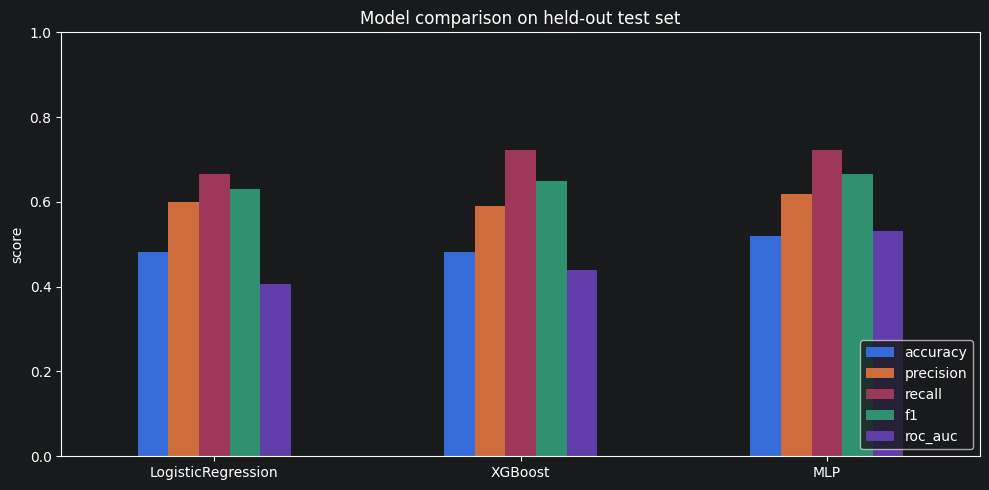

In [4]:
comparison = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1", "roc_auc"]]
display(comparison.style.format("{:.3f}").background_gradient(cmap="Greens"))

comparison.plot.bar(figsize=(10, 5))
plt.title("Model comparison on held-out test set")
plt.ylabel("score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Why each model is a good / bad choice

- **Logistic Regression** — strong, interpretable baseline; coefficients show which quizzes drive pass/fail. Weak if the boundary is non-linear or features interact heavily.
- **XGBoost** — captures non-linearities and feature interactions, handles correlated/unscaled features well; usually the best on small tabular data, but can overfit a small dataset and is less interpretable.
- **MLP** — flexible function approximator, but with only a couple hundred students it tends to overfit and rarely beats gradient boosting; needs careful regularisation (dropout) and more data to shine.